In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import os
from google.colab import userdata

!unzip \*.zip && rm *.zip

# Student Smoking, Alc, and Wellness dataset from: https://data.mendeley.com/datasets/7y66xb3gmc/2

Archive:  Student Smoking, Alcohol, and Psychological Wellne.zip
  inflating: Student Smoking, Alcohol, and Psychological Wellne/Student Smoking, Alcohol, and Mental Health Data.csv  
  inflating: Student Smoking, Alcohol, and Psychological Wellne/Student Smoking, Alcohol, and Mental Health Dataset_version-2.csv  


In [ ]:
!ls

 sample_data  'Student Smoking, Alcohol, and Psychological Wellne'


In [ ]:
df = pd.read_csv("/content/Student Smoking, Alcohol, and Psychological Wellne/Student Smoking, Alcohol, and Mental Health Dataset_version-2.csv")
dfa = df[df["Frequency of alcohol consumption"]!="Don’t consume alcohol"]
noal = df[df["Frequency of alcohol consumption"]=="Don’t consume alcohol"]
df.head(1)

,Timestamp,Age,Year of study,Field of study,Frequency of smoking,Age of starting smoking,Reasons for smoking,Frequency of alcohol consumption,Typical alcohol intake in a week,Reasons for consuming alcohol,To cope with stress,Help-seeking behavior for mental health,Interest in reducing or quitting smoking/alcohol consumption,Psychological Wellness
0,10/24/2024 8:12:57,24-26,Graduate student,Science and Technology,Don’t smoke,Don’t smoke,Don’t smoke,Don’t consume alcohol,Don’t drink alcohol,Don’t drink alcohol,Other,No,No,Good


In [ ]:
good_excellent_dfa = dfa[dfa['Psychological Wellness'].isin(['Good', 'Excellent'])]
good_excellent_noal = noal[noal['Psychological Wellness'].isin(['Good', 'Excellent'])]

comparison_data = {
    'Dataset': ['dfa (Alcohol)', 'noal (No Alcohol)'],
    'Good/Excellent Psychological Wellness Count': [len(good_excellent_dfa), len(good_excellent_noal)]
}
comparison_table = pd.DataFrame(comparison_data)
display(comparison_table)

,Dataset,Good/Excellent Psychological Wellness Count
0,dfa (Alcohol),33
1,noal (No Alcohol),80


In [ ]:
decent_dfa = dfa[dfa['Psychological Wellness'].isin(['Below average', 'Poor'])]
decent_noal = noal[noal['Psychological Wellness'].isin(['Below average', 'Poor'])]

comparison_data = {
    'Dataset': ['dfa (Alcohol)', 'noal (No Alcohol)'],
    'Decent/Poor Psychological Wellness Count': [len(decent_dfa), len(decent_noal)]
}
comparison_table = pd.DataFrame(comparison_data)
display(comparison_table)

,Dataset,Decent/Poor Psychological Wellness Count
0,dfa (Alcohol),996
1,noal (No Alcohol),15


In [ ]:
average_dfa = dfa[dfa['Psychological Wellness'].isin(['Average'])]
avgerage_noal = noal[noal['Psychological Wellness'].isin(['Average'])]

In [ ]:
goodin_df = len(good_excellent_dfa)/len(dfa)
goodin_noal = len(good_excellent_noal)/len(noal)
decentin_df = len(decent_dfa)/len(dfa)
decentin_noal = len(decent_noal)/len(noal)
avgin_df = len(average_dfa)/len(dfa)
avgin_noal = len(avgerage_noal)/len(noal)

In [ ]:
comparison_datat = {
    'Dataset': ['Alcohol', 'No Alcohol'],
    'Prevalence of Good/Excellent Psychological Wellness': [goodin_df, goodin_noal],
    'Prevalence of Average Psychological Wellness': [avgin_df, avgin_noal],
    'Prevalence of Below Average/Poor Psychological Wellness': [decentin_df, decentin_noal]
}
comparison_tabled = pd.DataFrame(comparison_datat)
display(comparison_tabled)

,Dataset,Prevalence of Good/Excellent Psychological Wellness,Prevalence of Average Psychological Wellness,Prevalence of Below Average/Poor Psychological Wellness
0,Alcohol,0.031220,0.02649,0.942289
1,No Alcohol,0.747664,0.11215,0.140187


In [ ]:
df["Year of study"].unique()

array(['Graduate student', '4th year', '3rd year', '1st year', '2nd year'],
      dtype=object)

/tmp/ipykernel_2657/147023634.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year of study', y='Number of Alcohol Drinkers', data=alcohol_by_year, palette='viridis')


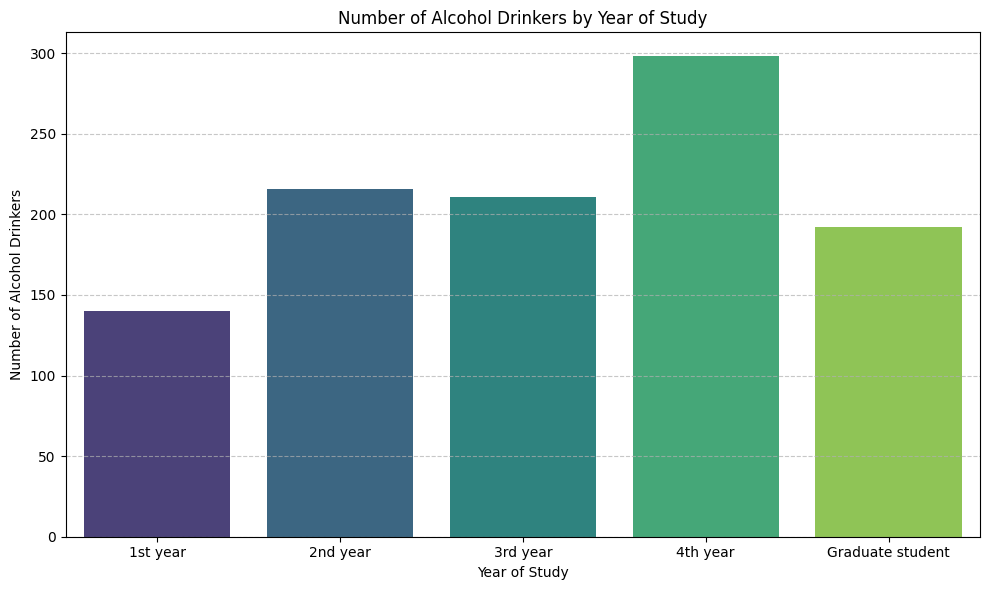

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

alcohol_by_year = dfa['Year of study'].value_counts().reset_index()
alcohol_by_year.columns = ['Year of study', 'Number of Alcohol Drinkers']

# Define the desired order for 'Year of study'
order = ['1st year', '2nd year', '3rd year', '4th year', 'Graduate student']

# Convert 'Year of study' to a categorical type with the specified order
alcohol_by_year['Year of study'] = pd.Categorical(alcohol_by_year['Year of study'], categories=order, ordered=True)

# Sort the DataFrame by the ordered 'Year of study'
alcohol_by_year = alcohol_by_year.sort_values('Year of study')

plt.figure(figsize=(10, 6))
sns.barplot(x='Year of study', y='Number of Alcohol Drinkers', data=alcohol_by_year, palette='viridis')
plt.title('Number of Alcohol Drinkers by Year of Study')
plt.xlabel('Year of Study')
plt.ylabel('Number of Alcohol Drinkers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()